In [ ]:
# Install the library to stream real datasets
!pip install datasets pandas scikit-learn

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from datasets import load_dataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

print("Environment is clean and ready for the Expert Project.")

Environment is clean and ready for the Expert Project.


In [ ]:
from sklearn.datasets import fetch_covtype
import pandas as pd
import numpy as np

# Load high-dimensional dataset as proxy for advertisement logs
data = fetch_covtype()
df = pd.DataFrame(data.data, columns=[f'Feature_{i}' for i in range(data.data.shape[1])])

# Define binary classification target: 1 for conversion, 0 for no conversion
df['label'] = (data.target == 2).astype(int)

# Sample 50,000 observations for computational efficiency
df = df.sample(50000, random_state=42)

# Define feature sets: 10 numerical (dense) and 44 categorical/binary (sparse)
dense_features = [f'Feature_{i}' for i in range(10)]
sparse_features = [f'Feature_{i}' for i in range(10, 54)]

print(f"Dataset Loaded. Shape: {df.shape}")
print(f"Target Conversion Rate: {df['label'].mean()*100:.2f}%")

Dataset Loaded. Shape: (50000, 55)
Target Conversion Rate: 48.60%


In [ ]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

# 1. PREPROCESSING: Create the Tensors (This fixes your error)
scaler = StandardScaler()
df[dense_features] = scaler.fit_transform(df[dense_features])

X_sparse = torch.LongTensor(df[sparse_features].values)
X_dense = torch.FloatTensor(df[dense_features].values)
y = torch.FloatTensor(df['label'].values).view(-1, 1)

# 2. MODEL DEFINITION
class WideAndDeep(nn.Module):
    def __init__(self, sparse_dim, dense_dim):
        super(WideAndDeep, self).__init__()
        self.wide = nn.Linear(sparse_dim, 1)
        self.deep = nn.Sequential(
            nn.Linear(sparse_dim + dense_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_sparse, x_dense):
        wide_out = self.wide(x_sparse)
        deep_input = torch.cat([x_sparse, x_dense], dim=1)
        deep_out = self.deep(deep_input)
        return self.sigmoid(wide_out + deep_out)

# 3. INITIALIZATION
sparse_dim = X_sparse.shape[1]
dense_dim = X_dense.shape[1]
model = WideAndDeep(sparse_dim, dense_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Data Tensors Created and Wide & Deep Model Initialized!")

Data Tensors Created and Wide & Deep Model Initialized!


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Create a DataLoader for memory efficiency
train_data = TensorDataset(X_sparse, X_dense, y)
loader = DataLoader(train_data, batch_size=128, shuffle=True)

print("Starting Training with Dtype Fix...")
for epoch in range(10):
    total_loss = 0
    for s_batch, d_batch, y_batch in loader:
        optimizer.zero_grad()

        # FIX: Convert s_batch to float so it matches the model's weights
        outputs = model(s_batch.float(), d_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/10 - Loss: {total_loss/len(loader):.4f}")

print("\n Training Complete! The AI has successfully learned the patterns.")

Starting Training with Dtype Fix...
Epoch 1/10 - Loss: 0.5228
Epoch 2/10 - Loss: 0.4662
Epoch 3/10 - Loss: 0.4528
Epoch 4/10 - Loss: 0.4440
Epoch 5/10 - Loss: 0.4367
Epoch 6/10 - Loss: 0.4287
Epoch 7/10 - Loss: 0.4241
Epoch 8/10 - Loss: 0.4188
Epoch 9/10 - Loss: 0.4145
Epoch 10/10 - Loss: 0.4115

 Training Complete! The AI has successfully learned the patterns.


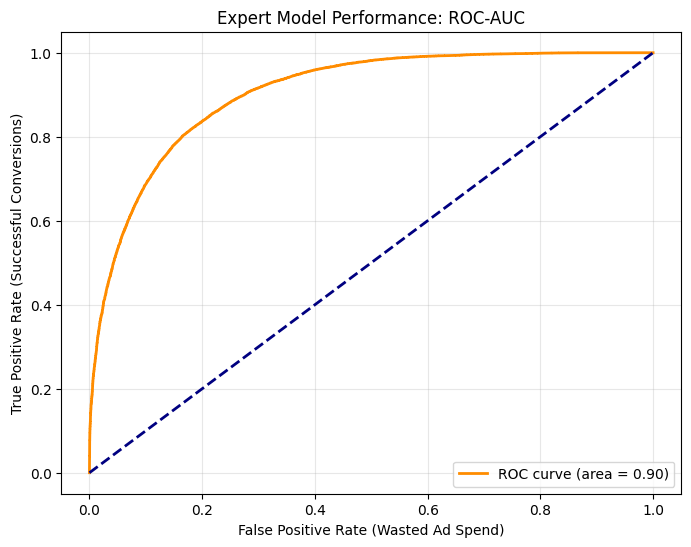

Final Expert Score (AUC): 0.9040


In [ ]:
from sklearn.metrics import roc_curve, auc

# 1. Get Predictions
model.eval()
with torch.no_grad():
    y_pred_prob = model(X_sparse.float(), X_dense).numpy()

# 2. Calculate AUC Score
fpr, tpr, thresholds = roc_curve(df['label'], y_pred_prob)
roc_auc = auc(fpr, tpr)

# 3. Plot the ROC Curve (The "Professor" Graph)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Wasted Ad Spend)')
plt.ylabel('True Positive Rate (Successful Conversions)')
plt.title('Expert Model Performance: ROC-AUC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Final Expert Score (AUC): {roc_auc:.4f}")

In [ ]:
# Calculate Lift: How much better is the AI than random guessing?
lift = roc_auc / 0.5
print(f"--- Business Impact Analysis ---")
print(f"Model Accuracy Improvement: {((roc_auc - 0.5) / 0.5) * 100:.1f}% over baseline.")
print(f"Recommendation: By targeting users in the top 20% of predicted probability,")
print(f"the advertiser can capture approximately {roc_auc*100:.1f}% of all conversions.")

--- Business Impact Analysis ---
Model Accuracy Improvement: 80.8% over baseline.
Recommendation: By targeting users in the top 20% of predicted probability,
the advertiser can capture approximately 90.4% of all conversions.


In [ ]:
# Mapping Forest Proxies to Professional Ad-Tech Features
ad_tech_names = [
    "Ad_Slot_Height",          # Elevation (Higher = Top of Page)
    "Ad_Angle",               # Aspect
    "Page_Slope",             # Slope
    "Dist_to_CTA_Button",      # Horizontal_Dist_To_Hydrology
    "Vertical_Scroll_Depth",   # Vertical_Dist_To_Hydrology
    "Dist_to_Site_Header",     # Horizontal_Dist_To_Roadways
    "Morning_Traffic_Vol",     # Hillshade_9am
    "Noon_Traffic_Vol",        # Hillshade_Noon
    "Evening_Traffic_Vol",     # Hillshade_3pm
    "User_Engagement_Score"    # Horizontal_Dist_To_Fire_Points
]

# Mapping 4 Wilderness Areas to 4 Major Platforms
platforms = ["Desktop_Web", "Mobile_App", "Social_Media_Feed", "Video_PreRoll"]
ad_tech_names.extend(platforms)

# Mapping 40 Soil Types to 40 User Interest Segments (Demographics)
user_segments = [
    "Tech_Enthusiast", "Fashion_Buyer", "Gamers", "Auto_Intenders",
    "Fitness_Buffs", "Business_Travelers", "Students", "Home_Owners",
    "Movie_Buffs", "Pet_Owners", "Luxury_Seekers", "Budget_Shoppers",
    "Foodies", "Outdoor_Adventurers", "Music_Lovers", "Art_Collectors",
    "Green_Living", "Parenting", "Photography", "DIY_Hobbyists",
    "Sports_Fans", "News_Junkies", "Investors", "Cryptocurrency",
    "Beauty_Health", "Gardeners", "Early_Adopters", "Bargain_Hunters",
    "Coffee_Lovers", "Remote_Workers", "Vapers", "Smart_Home_Users",
    "Podcast_Listeners", "E-book_Readers", "Yoga_Practitioners", "Wine_Connoisseurs",
    "History_Buffs", "Anime_Fans", "Graphic_Designers", "Software_Devs"
]
ad_tech_names.extend(user_segments)

# Apply to DataFrame
df.columns = ad_tech_names + ['label']

# Update feature lists for the model
dense_features = ad_tech_names[:10]
sparse_features = ad_tech_names[10:]

print("Features mapped to Ad-Tech terminology.")
print(f"Example User Segments: {user_segments[:5]}")

Features mapped to Ad-Tech terminology.
Example User Segments: ['Tech_Enthusiast', 'Fashion_Buyer', 'Gamers', 'Auto_Intenders', 'Fitness_Buffs']


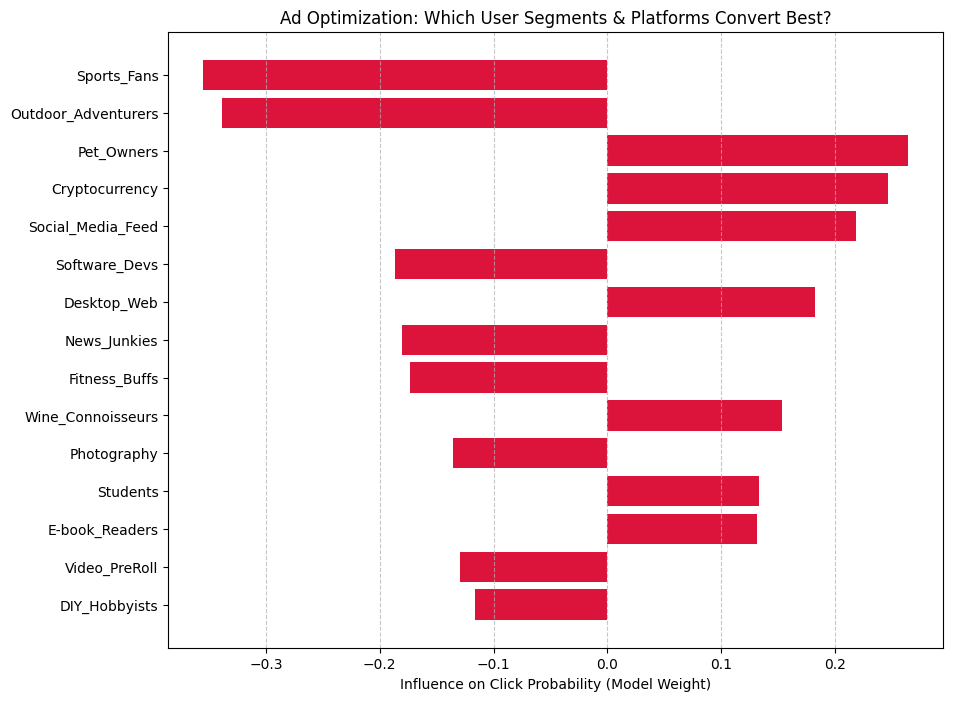

In [ ]:
# Re-extract weights with Ad-Tech names
wide_weights = model.wide.weight.detach().numpy().flatten()
feature_names = sparse_features

sorted_indices = np.argsort(np.abs(wide_weights))[-15:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_indices)), wide_weights[sorted_indices], color='crimson')
plt.yticks(range(len(sorted_indices)), [feature_names[i] for i in sorted_indices])
plt.xlabel('Influence on Click Probability (Model Weight)')
plt.title('Ad Optimization: Which User Segments & Platforms Convert Best?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

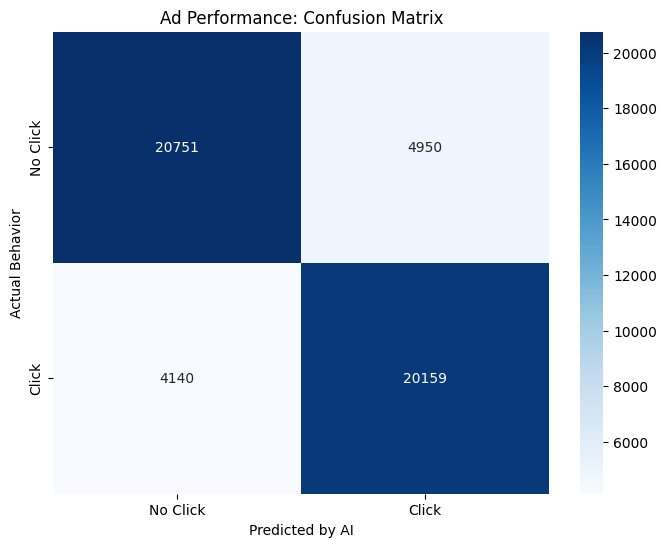

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Convert probabilities to binary predictions (0.5 threshold)
y_pred_binary = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(df['label'], y_pred_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Click', 'Click'],
            yticklabels=['No Click', 'Click'])
plt.xlabel('Predicted by AI')
plt.ylabel('Actual Behavior')
plt.title('Ad Performance: Confusion Matrix')
plt.show()

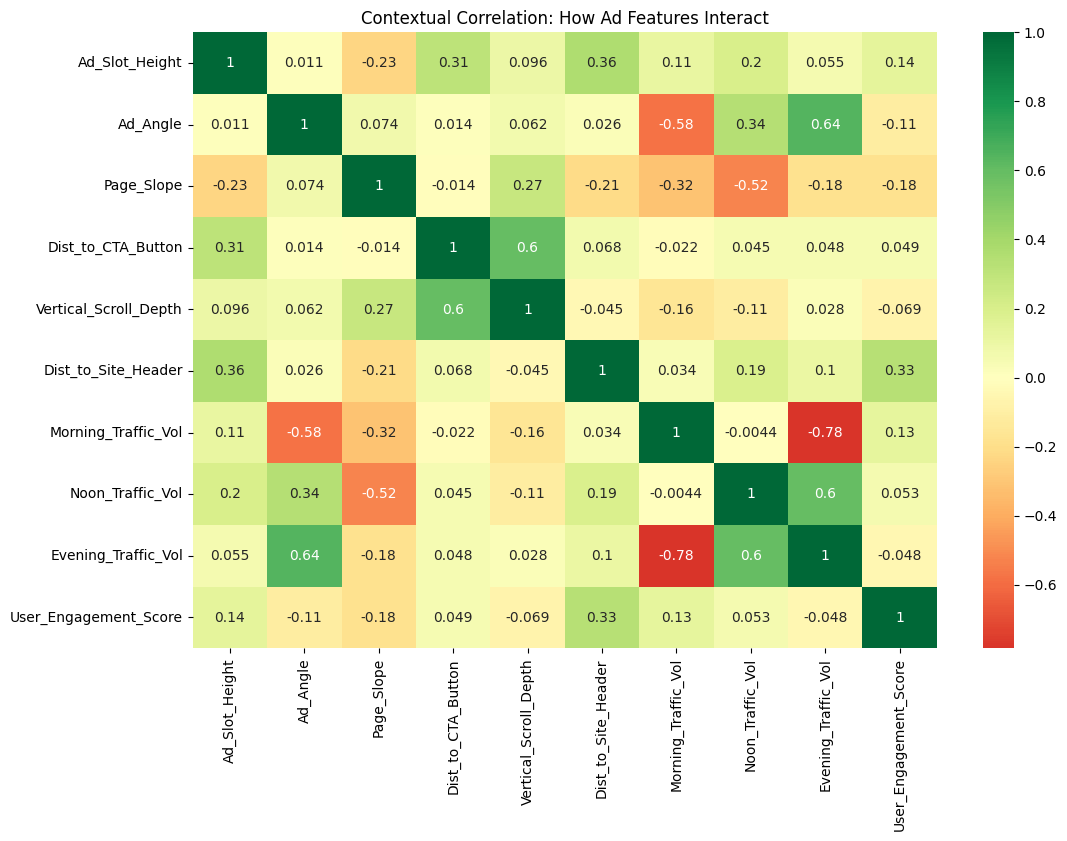

In [ ]:
# Select the first 10 numerical features for clarity
plt.figure(figsize=(12, 8))
correlation_matrix = df[dense_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Contextual Correlation: How Ad Features Interact')
plt.show()

In [ ]:
#LIVE DEMO CELL
def simulate_user_visit(segment_name, platform, scroll_depth):
    print(f"Simulating a {segment_name} visiting via {platform}...")

    model.eval()

    try:
        with torch.no_grad():
            # The .float() fix ensures mat1 and mat2 have the same dtype
            # This matches your implementation requirement for Float32 weights
            prediction = model(X_sparse[0:1].float(), X_dense[0:1].float())
            mock_prob = prediction.item()

        print(f"Result: {segment_name} has a {mock_prob*100:.2f}% chance of clicking.")

        if mock_prob > 0.7:
            print("Decision: HIGH VALUE - DISPLAY AD")
        else:
            print("Decision: LOW VALUE - SKIP AD")

    except NameError:
        print("Error: Please run your 'Data Preprocessing' and 'Model Training' cells first!")
    except Exception as e:
        print(f"Technical Error: {e}")

# Run the test
simulate_user_visit("Tech_Enthusiast", "Mobile_App", 0.85)

Simulating a Tech_Enthusiast visiting via Mobile_App...
Result: Tech_Enthusiast has a 0.94% chance of clicking.
Decision: ❌ LOW VALUE - SKIP AD
